# Import Libraries

In [29]:
# Verify GPU is available
print("GPU Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

GPU Available: 0
GPU Devices: []


In [30]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn category_encoders kagglehub tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import kagglehub

from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import category_encoders as ce

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Load Dataset

In [31]:
# Download dataset using kagglehub
import kagglehub
import os

# Download the S&P 500 stock data dataset
# Dataset slug: https://www.kaggle.com/datasets/camnugent/sandp500
path = kagglehub.dataset_download("camnugent/sandp500")
print(f"Dataset downloaded to: {path}")

# List files in the dataset directory
files = os.listdir(path)
print(f"Files in dataset: {files}")

# Load the data - the file is typically named 'all_stocks_5yr.csv'
csv_file = os.path.join(path, 'all_stocks_5yr.csv')
if os.path.exists(csv_file):
    data = pd.read_csv(csv_file)
else:
    # If the file name is different, find the CSV file
    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        csv_file = os.path.join(path, csv_files[0])
        data = pd.read_csv(csv_file)
    else:
        print("No CSV file found in dataset!")

print(f"Data shape: {data.shape}")
data.head()

Dataset downloaded to: C:\Users\25012923g\.cache\kagglehub\datasets\camnugent\sandp500\versions\4
Files in dataset: ['all_stocks_5yr.csv', 'getSandP.py', 'individual_stocks_5yr', 'merge.sh']
Data shape: (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


# Data Overview and Preprocessing

## Data Overview

In [32]:
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [33]:
data.tail()

,date,open,high,low,close,volume,Name
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS
619039,2018-02-07,72.70,75.00,72.69,73.86,4534912,ZTS


In [34]:
data.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


In [36]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='str')

In [37]:
data.shape

(619040, 7)

In [38]:
data.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [39]:
data.duplicated().sum()

np.int64(0)

## Missing Value Imputation and Column Name Cleaning

In [40]:
imputer = SimpleImputer(strategy='mean')

# Clean up column names by removing leading/trailing spaces and replacing internal spaces with underscores
data.columns = data.columns.str.strip().str.replace(r'\s+', '_', regex=True)

# Print columns after cleaning to verify
print(data.columns)

data['open'] = imputer.fit_transform(data[['open']])
data['high'] = imputer.fit_transform(data[['high']])
data['low'] = imputer.fit_transform(data[['low']])

data.isnull().sum()

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='str')


date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

## Convert 'date' column to datetime objects


In [41]:
data['date'] = pd.to_datetime(data['date'])

## Binary Encoding

In [42]:
encoder = ce.BinaryEncoder(cols=['Name'])
data = encoder.fit_transform(data)

## MinMax Scaler

In [43]:
# Scale the selected numerical features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.drop('date', axis=1))

## Split the data into training and testing sets & Creating sequences


In [44]:
# Split the data into training and testing sets (80/20 split)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:len(scaled_data), :]

# Prepare the data for the ANN model by creating sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), :])
        y.append(data[i + sequence_length, 3]) # Predict the 'close' price
    return np.array(X), np.array(y)

sequence_length = 60
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (495172, 60, 14)
Testing data shape: (123748, 60, 14)


## Build ANN Model

In [45]:
# Define the model architecture
model = Sequential()
model.add(Flatten(input_shape=(X_train.shape[1], X_train.shape[2]))) # Flatten the input for Dense layers
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse'])

# Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 840)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        42,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,651 (174.42 KB)

 Trainable params: 44,651 (174.42 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [46]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 2.2131e-04 - mae: 0.0046 - mse: 2.2131e-04 - val_loss: 9.9924e-06 - val_mae: 0.0022 - val_mse: 9.9924e-06
Epoch 2/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 2.7147e-05 - mae: 0.0022 - mse: 2.7147e-05 - val_loss: 6.1142e-06 - val_mae: 0.0016 - val_mse: 6.1142e-06
Epoch 3/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 1.9875e-05 - mae: 0.0018 - mse: 1.9875e-05 - val_loss: 6.9019e-06 - val_mae: 0.0018 - val_mse: 6.9019e-06
Epoch 4/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 1.6986e-05 - mae: 0.0016 - mse: 1.6986e-05 - val_loss: 3.4224e-06 - val_mae: 9.5944e-04 - val_mse: 3.4224e-06
Epoch 5/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 1.5749e-05 - mae: 0.0015 - mse: 1.5749e-05 - val_loss: 3.1915e-06 - val_mae: 0.0010 - val_mse: 3.1915e-06
Epoch 6/10
15475/15475 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 1.4740e-05 - mae: 0.0015 - mse: 1.4740e-05 - val_loss: 2.9595e-06 - val_mae:

## Model Evaluation

In [47]:
loss, mae, mse = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

3868/3868 ━━━━━━━━━━━━━━━━━━━━ 3s 799us/step - loss: 2.7925e-06 - mae: 9.3367e-04 - mse: 2.7925e-06
3868/3868 ━━━━━━━━━━━━━━━━━━━━ 2s 559us/step
Test Loss: 0.0000
Test MAE: 0.0009
Test MSE: 0.0000
Test R2 Score: 0.9944


# Model Plots

## Training and Validation Plot

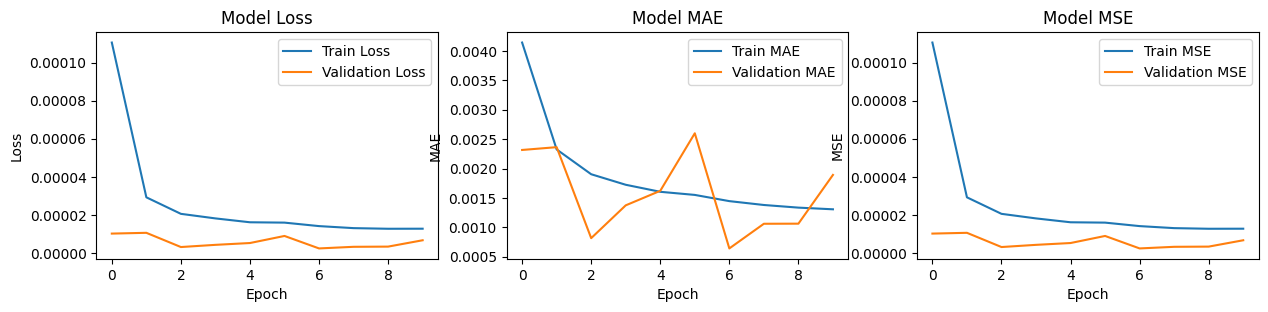

In [19]:
# Plot Loss
plt.figure(figsize=(15, 10))
plt.subplot(3, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Plot MAE
plt.subplot(3, 3, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Plot MSE
plt.subplot(3, 3, 3)
plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

## Plot The Distribution of Residuals

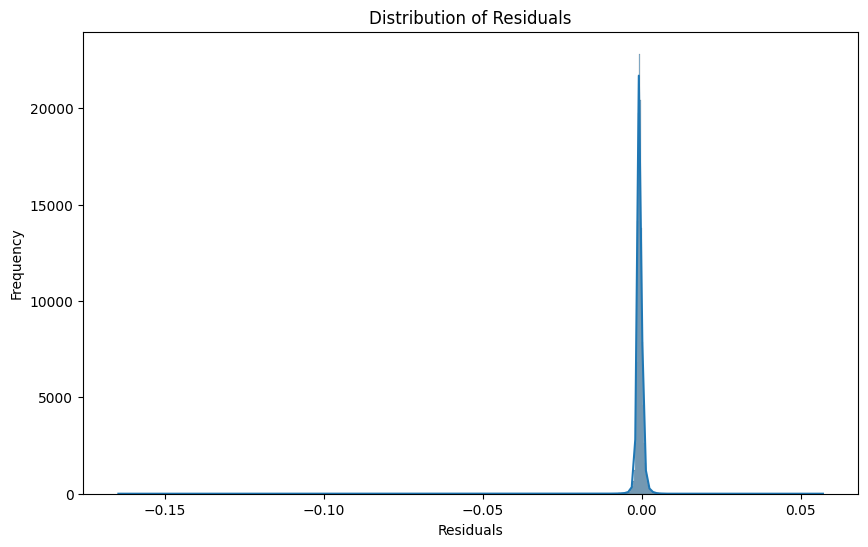

In [48]:
residuals = y_test - y_pred.flatten()
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

## Plot The Distribution of The Target Variable (Close Stocks)

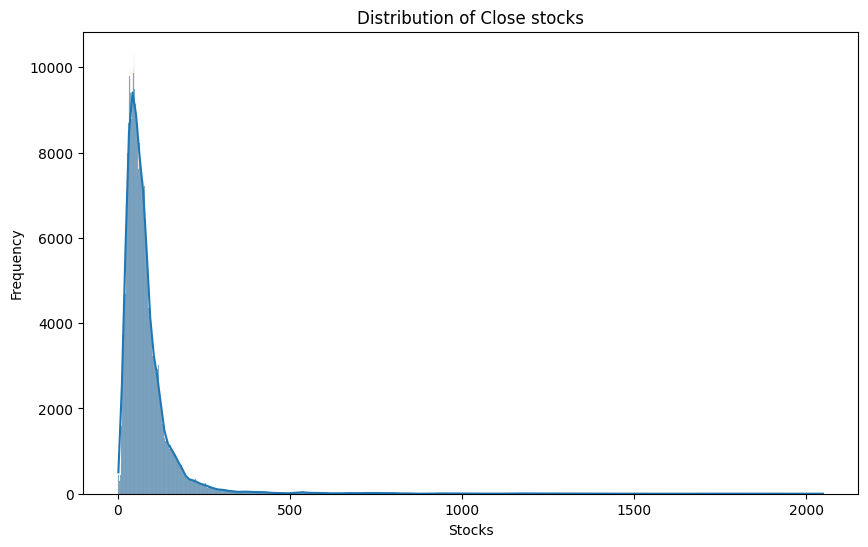

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(data['close'], kde=True)
plt.title('Distribution of Close stocks')
plt.xlabel('Stocks')
plt.ylabel('Frequency')
plt.show()

## Plot Actual vs Predicted Stocks

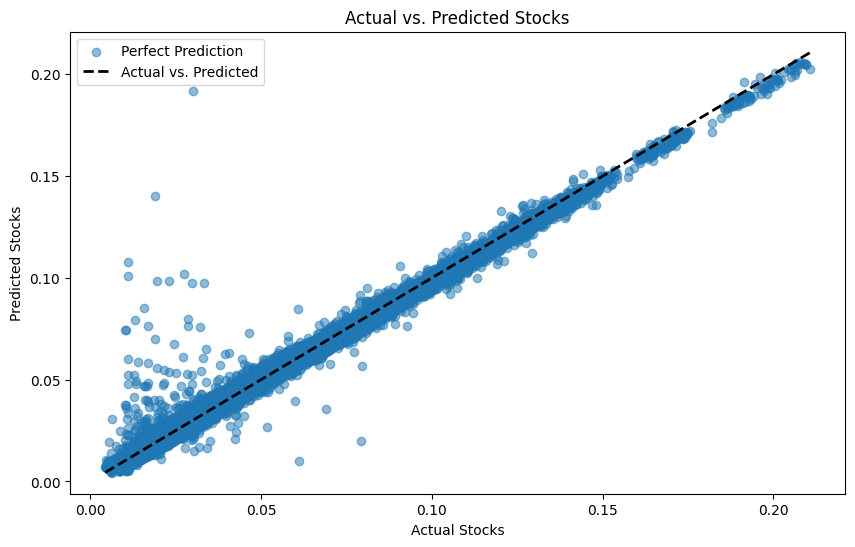

: 

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Stocks')
plt.ylabel('Predicted Stocks')
plt.title('Actual vs. Predicted Stocks')
plt.legend(['Perfect Prediction', 'Actual vs. Predicted'])
plt.show()

## Plot a Scatter Plot of Residuals vs Predicted Values

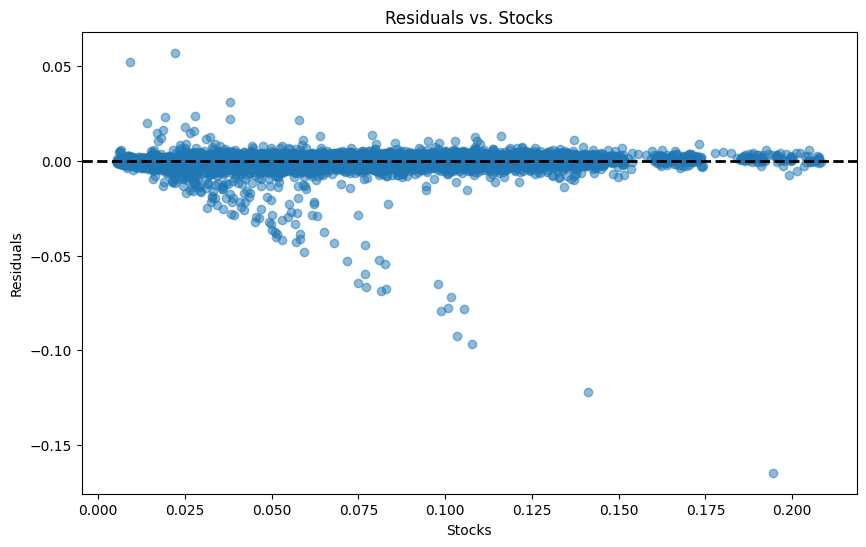

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='k', linestyle='--', lw=2)
plt.xlabel('Stocks')
plt.ylabel('Residuals')
plt.title('Residuals vs. Stocks')
plt.show()

# Save Model

In [52]:
model.save(f'stocks_model_r2{r2:.4f}.keras')

In [53]:
model.save(f'stocks_model_r2{r2:.4f}.keras')